Load the Track 2 starter data, inspect its structure, calculate per-channel statistics, and document initial findings.

In [ ]:
%pip install neuralbench "moabb>=1.7.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 980.1/980.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.2/679.2 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.9/267.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from importlib.metadata import version

for package in ["neuralbench", "moabb", "mne"]:
    print(f"{package}: {version(package)}")

neuralbench: 0.3.1
moabb: 1.7.2
mne: 1.13.2


In [ ]:
import neuralbench
import moabb
import mne

print("All three packages imported successfully.")

/usr/local/lib/python3.13/dist-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/usr/local/lib/python3.13/dist-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1020")


All three packages imported successfully.


In [ ]:
import moabb.datasets as datasets
import shutil

dreyer_loaders = [
    name for name in dir(datasets)
    if "dreyer" in name.lower()
]
print("Available Dreyer loaders:", dreyer_loaders)

free_gb = shutil.disk_usage("/content").free / (1024 ** 3)
print(f"Available Colab storage: {free_gb:.1f} GB")

Available Dreyer loaders: ['Dreyer2023', 'Dreyer2023A', 'Dreyer2023B', 'Dreyer2023C', 'dreyer2023']
Available Colab storage: 86.6 GB


In [ ]:
from moabb.datasets import Dreyer2023
import inspect

# Include auxiliary channels if this installed version supports it.
options = {}
if "return_all_modalities" in inspect.signature(Dreyer2023).parameters:
    options["return_all_modalities"] = True

dataset = Dreyer2023(**options)
subject_id = dataset.subject_list[0]

print("Loading subject:", subject_id)
print("Label-to-event mapping:", dataset.event_id)

# Downloads the selected participant's files if needed.
data = dataset.get_data(subjects=[subject_id])

for session_id, runs in data[subject_id].items():
    for run_id, raw in runs.items():
        print(
            f"Session {session_id}, run {run_id}: "
            f"{len(raw.ch_names)} channels, "
            f"{raw.info['sfreq']} Hz, "
            f"{raw.n_times / raw.info['sfreq']:.1f} seconds"
        )

Loading subject: 1
Label-to-event mapping: {'left_hand': 1, 'right_hand': 2}
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
This is nemar-py 0.3.3.
Preparing to download nm000250 from https://data.nemar.org/
Retrieving 5 of 4087 manifest files (16 concurrent downloads).


Overall:   0%|          | 0.00/135k [00:00<?, ?B/s]

Finished downloading nm000250 v1.0.5.
This is nemar-py 0.3.3.
Preparing to download nm000250 from https://data.nemar.org/
Retrieving 10 of 4087 manifest files (16 concurrent downloads).


S3:   0%|          | 0.00/84.8M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/moabb/datasets/download.py:827: RuntimeWarning: Directory /root/mne_data/MNE-dreyer2023-data not found. Creating directory.
  warn(f"Directory {folder_path} not found. Creating directory.")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/download.py:836: RuntimeWarning: /root/mne_data/MNE-dreyer2023-data/dreyer2023_manifest.tsv not found. Downloading from https://osf.io/download/p5av2/
  warn(f"{file_path} not found. Downloading from {url}")


...

  0%|                                              | 0.00/1.39M [00:00<?, ?B/s]

SHA256 hash of downloaded file: a5bc6906cced90e49bf288ccb0fd78c2f6359d0631a4f6178a9f0f2723d39bc2
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
8it [00:08,  1.14s/it]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa76e4ba1d657fd7556' to file '/root/mne_data/MNE-dreyer2023-data/sub-01.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3futu

  0%|                                              | 0.00/72.6M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 7c9b290700381e9f06025eb3248d8118eae57d6ae36c393f4d265596c63a82c1
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:14,  1.56s/it]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Session 0, run 0R1acquisition: 32 channels, 512.0 Hz, 450.0 seconds
Session 0, run 1R2acquisition: 32 channels, 512.0 Hz, 450.0 seconds
Session 0, run 2R3online: 32 channels, 512.0 Hz, 451.0 seconds
Session 0, run 3R4online: 32 channels, 512.0 Hz, 451.0 seconds
Session 0, run 4R5online: 32 channels, 512.0 Hz, 451.0 seconds
Session 0, run 5R6online: 32 channels, 512.0 Hz, 451.0 seconds


In [ ]:
import pandas as pd

# Select the first session and first run for inspection.
session_id = next(iter(data[subject_id]))
run_id = next(iter(data[subject_id][session_id]))
raw_example = data[subject_id][session_id][run_id]

channel_table = pd.DataFrame({
    "channel": raw_example.ch_names,
    "type": raw_example.get_channel_types()
})

display(channel_table)
print("Channel counts:")
print(channel_table["type"].value_counts())

,channel,type
0,Fz,eeg
1,FCz,eeg
2,Cz,eeg
3,CPz,eeg
4,Pz,eeg
5,C1,eeg
6,C3,eeg
7,C5,eeg
8,C2,eeg
9,C4,eeg


Channel counts:
type
eeg    27
eog     3
emg     2
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

rows = []

for session_id, runs in data[subject_id].items():
    for run_id, raw in runs.items():
        emg_names = [
            name
            for name, kind in zip(raw.ch_names, raw.get_channel_types())
            if kind == "emg"
        ]

        signals = raw.get_data(
            picks=emg_names,
            units={"emg": "uV"}
        )

        for channel, signal in zip(emg_names, signals):
            valid = signal[np.isfinite(signal)]

            rows.append({
                "subject": subject_id,
                "session": session_id,
                "run": run_id,
                "channel": channel,
                "mean_uV": valid.mean() if valid.size else np.nan,
                "std_uV": valid.std(ddof=0) if valid.size else np.nan,
                "invalid_samples": signal.size - valid.size,
                "flat_channel": (
                    bool(np.ptp(valid) == 0) if valid.size else None
                )
            })

emg_run_stats = pd.DataFrame(rows)
display(emg_run_stats)

,subject,session,run,channel,mean_uV,std_uV,invalid_samples,flat_channel
0,1,0,0R1acquisition,EMGg,7571.586226,3481.740642,0,False
1,1,0,0R1acquisition,EMGd,-130.946463,2933.514487,0,False
2,1,0,1R2acquisition,EMGg,16984.786209,1411.201420,0,False
3,1,0,1R2acquisition,EMGd,8090.574841,1537.692764,0,False
4,1,0,2R3online,EMGg,13835.828794,1704.020639,0,False
5,1,0,2R3online,EMGd,9017.753466,1347.829218,0,False
6,1,0,3R4online,EMGg,17952.010614,1103.836985,0,False
7,1,0,3R4online,EMGd,13075.940859,1171.083785,0,False
8,1,0,4R5online,EMGg,15147.655130,1746.518819,0,False
9,1,0,4R5online,EMGd,9527.299247,1771.073149,0,False


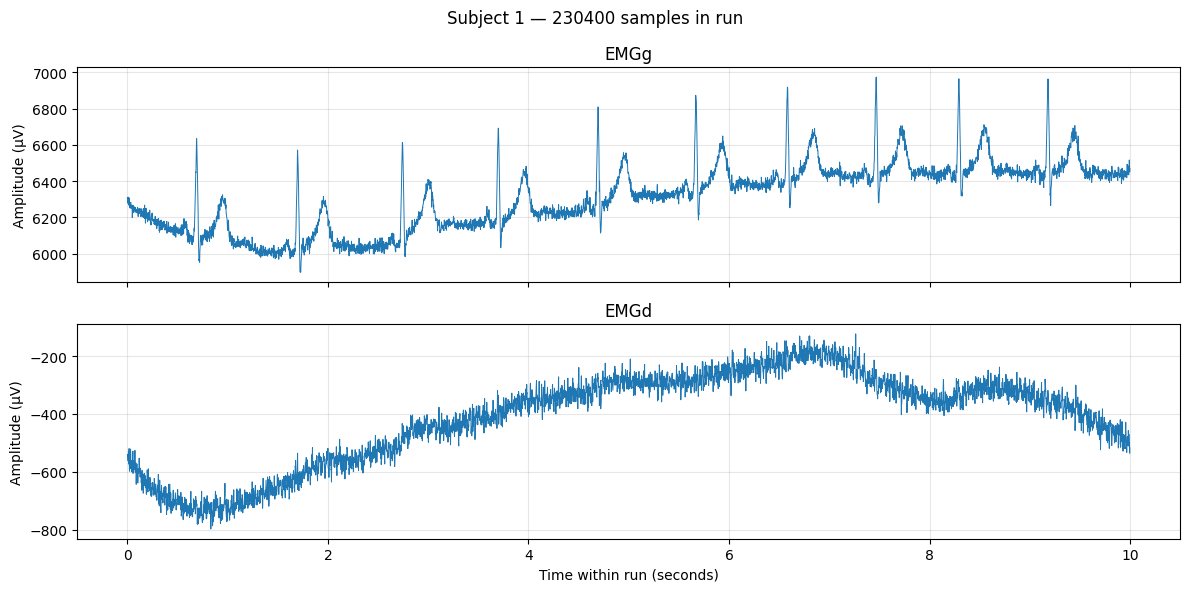

In [ ]:
import matplotlib.pyplot as plt

emg_names = [
    name
    for name, kind in zip(
        raw_example.ch_names, raw_example.get_channel_types()
    )
    if kind == "emg"
]

stop = min(
    int(10 * raw_example.info["sfreq"]),
    raw_example.n_times
)

signals, times = raw_example.get_data(
    picks=emg_names,
    start=0,
    stop=stop,
    units={"emg": "uV"},
    return_times=True
)

fig, axes = plt.subplots(
    len(emg_names), 1, figsize=(12, 6), sharex=True
)

for ax, name, signal in zip(axes, emg_names, signals):
    ax.plot(times, signal, linewidth=0.7)
    ax.set_title(name)
    ax.set_ylabel("Amplitude (µV)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time within run (seconds)")
fig.suptitle(f"Subject {subject_id} — {raw_example.n_times} samples in run")
plt.tight_layout()
plt.show()

In [ ]:
import inspect

print(inspect.getsource(type(dataset)._get_single_subject_data))

    def _get_single_subject_data(self, subject):
        """Return the data of a single subject.

        Parameters
        ----------
        subject : int
            The subject number to fetch data for.

        Returns
        -------
        dict
            A dictionary containing the raw data for the subject.
        """
        # Get the file path for the subject's data
        files_path = self.data_path(subject)
        runs = {}
        for run_id, file in enumerate(files_path):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                # Read the subject's raw data and set the montage
                raw = read_raw_bids(bids_path=file, verbose=False)
                raw = raw.load_data()

                # Set the channel montage
                mapping = {}
                for ch in raw.ch_names:
                    if "EOG" in ch:
                        mapping[ch] = "eog"
                    elif "EMG" in ch:
          

In [ ]:
from pathlib import Path
import pandas as pd

recording_path = Path(raw_example.filenames[0])
print("Recording file:", recording_path.name)

# Locate the channel metadata belonging to this recording.
prefix = recording_path.name.rsplit("_eeg", 1)[0]
channels_path = recording_path.parent / f"{prefix}_channels.tsv"

if channels_path.exists():
    channel_metadata = pd.read_csv(channels_path, sep="\t")
    emg_rows = channel_metadata["name"].str.contains(
        "EMG", case=False, na=False
    )
    display(channel_metadata.loc[emg_rows])
else:
    print("Exact metadata file not found. Available channel files:")
    for path in recording_path.parent.glob("*channels.tsv"):
        print(path.name)

Recording file: sub-01_task-R1acquisition_eeg.edf
Exact metadata file not found. Available channel files:
sub-01_task-CEbaseline_channels.tsv


In [ ]:
with open(recording_path, "rb") as file:
    header = file.read(256)
    n_channels = int(header[252:256].decode("ascii").strip())

    fields = {}
    for name, width in [
        ("channel", 16),
        ("transducer", 80),
        ("source_unit", 8),
        ("physical_min", 8),
        ("physical_max", 8),
        ("digital_min", 8),
        ("digital_max", 8),
        ("prefilter", 80),
    ]:
        block = file.read(n_channels * width)
        fields[name] = [
            block[i * width:(i + 1) * width]
            .decode("ascii", errors="replace").strip()
            for i in range(n_channels)
        ]

edf_metadata = pd.DataFrame(fields)

display(
    edf_metadata[
        edf_metadata["channel"].str.contains("EMG", case=False)
    ]
)

,channel,transducer,source_unit,physical_min,physical_max,digital_min,digital_max,prefilter
14,EMGg,,uV,-5454.84,15279.64,-32767,32767,HP:0.0Hz LP:256.0Hz N:NoneHz
15,EMGd,,uV,-5454.84,15279.64,-32767,32767,HP:0.0Hz LP:256.0Hz N:NoneHz


In [ ]:
trial_count_rows = []

for session_id, runs in data[subject_id].items():
    for run_id, raw in runs.items():
        descriptions = pd.Series(raw.annotations.description)

        trial_count_rows.append({
            "subject": subject_id,
            "session": session_id,
            "run": run_id,
            "left_hand": int((descriptions == "left_hand").sum()),
            "right_hand": int((descriptions == "right_hand").sum()),
        })

trial_counts = pd.DataFrame(trial_count_rows)
display(trial_counts)

print("Total cue counts:")
print(trial_counts[["left_hand", "right_hand"]].sum())

,subject,session,run,left_hand,right_hand
0,1,0,0R1acquisition,20,20
1,1,0,1R2acquisition,20,20
2,1,0,2R3online,20,20
3,1,0,3R4online,20,20
4,1,0,4R5online,20,20
5,1,0,5R6online,20,20


Total cue counts:
left_hand     120
right_hand    120
dtype: int64


In [ ]:
print("Dataset trial interval:", dataset.interval)
print("Label mapping:", dataset.event_id)

annotations = pd.DataFrame({
    "onset_seconds": raw_example.annotations.onset,
    "duration_seconds": raw_example.annotations.duration,
    "label": raw_example.annotations.description,
})

display(
    annotations[
        annotations["label"].isin(["left_hand", "right_hand"])
    ].head(10)
)

Dataset trial interval: [0, 5]
Label mapping: {'left_hand': 1, 'right_hand': 2}


,onset_seconds,duration_seconds,label
0,7.998047,5.0,left_hand
1,17.998047,5.0,left_hand
2,29.000000,5.0,right_hand
3,38.998047,5.0,left_hand
4,51.000000,5.0,right_hand
5,62.000000,5.0,left_hand
6,72.998047,5.0,right_hand
7,84.000000,5.0,right_hand
8,95.998047,5.0,left_hand
9,107.998047,5.0,left_hand


In [ ]:
trial_rows = []
skipped_trials = 0

for session_id, runs in data[subject_id].items():
    for run_id, raw in runs.items():
        sfreq = raw.info["sfreq"]
        window_samples = int(round(5 * sfreq))

        emg_names = [
            name
            for name, kind in zip(raw.ch_names, raw.get_channel_types())
            if kind == "emg"
        ]

        trial_number = 0

        for onset, label in zip(
            raw.annotations.onset,
            raw.annotations.description
        ):
            if label not in ["left_hand", "right_hand"]:
                continue

            trial_number += 1
            start = int(raw.time_as_index(
                onset - raw.first_time, use_rounding=True
            )[0])
            stop = start + window_samples

            if start < 0 or stop > raw.n_times:
                skipped_trials += 1
                continue

            signals = raw.get_data(
                picks=emg_names,
                start=start,
                stop=stop,
                units={"emg": "uV"}
            )

            for channel, signal in zip(emg_names, signals):
                valid = signal[np.isfinite(signal)]

                trial_rows.append({
                    "subject": subject_id,
                    "session": session_id,
                    "run": run_id,
                    "trial": trial_number,
                    "label": label,
                    "channel": channel,
                    "mean_uV": valid.mean() if valid.size else np.nan,
                    "std_uV": valid.std(ddof=0) if valid.size else np.nan,
                    "invalid_samples": signal.size - valid.size
                })

emg_trial_stats = pd.DataFrame(trial_rows)

display(emg_trial_stats.head(10))
print("Trial-channel rows:", len(emg_trial_stats))
print("Trials skipped at recording boundaries:", skipped_trials)

,subject,session,run,trial,label,channel,mean_uV,std_uV,invalid_samples
0,1,0,0R1acquisition,1,left_hand,EMGg,6430.414785,112.243399,0
1,1,0,0R1acquisition,1,left_hand,EMGd,-529.162619,145.366747,0
2,1,0,0R1acquisition,2,left_hand,EMGg,6430.627732,143.712689,0
3,1,0,0R1acquisition,2,left_hand,EMGd,-401.760296,120.542312,0
4,1,0,0R1acquisition,3,right_hand,EMGg,6721.327255,95.148072,0
5,1,0,0R1acquisition,3,right_hand,EMGd,-101.874632,45.010552,0
6,1,0,0R1acquisition,4,left_hand,EMGg,6963.899986,105.921555,0
7,1,0,0R1acquisition,4,left_hand,EMGd,-21.776851,44.248817,0
8,1,0,0R1acquisition,5,right_hand,EMGg,6435.260537,102.000197,0
9,1,0,0R1acquisition,5,right_hand,EMGd,-1049.468951,152.435513,0


Trial-channel rows: 480
Trials skipped at recording boundaries: 0


In [ ]:
emg_summary = (
    emg_trial_stats
    .groupby(["run", "label", "channel"], as_index=False)
    .agg(
        n_trials=("trial", "count"),
        average_trial_mean_uV=("mean_uV", "mean"),
        average_trial_std_uV=("std_uV", "mean"),
        invalid_samples=("invalid_samples", "sum")
    )
)

display(emg_summary.round(2))

print(
    "Total invalid samples across all trial windows:",
    emg_trial_stats["invalid_samples"].sum()
)

,run,label,channel,n_trials,average_trial_mean_uV,average_trial_std_uV,invalid_samples
0,0R1acquisition,left_hand,EMGd,20,14.56,95.32,0
1,0R1acquisition,left_hand,EMGg,20,7702.98,175.30,0
2,0R1acquisition,right_hand,EMGd,20,-562.62,144.11,0
3,0R1acquisition,right_hand,EMGg,20,7130.92,237.22,0
4,1R2acquisition,left_hand,EMGd,20,8216.25,67.31,0
5,1R2acquisition,left_hand,EMGg,20,17097.72,113.67,0
6,1R2acquisition,right_hand,EMGd,20,7987.91,54.67,0
7,1R2acquisition,right_hand,EMGg,20,16916.20,104.76,0
8,2R3online,left_hand,EMGd,20,8917.95,58.39,0
9,2R3online,left_hand,EMGg,20,13718.71,136.73,0


Total invalid samples across all trial windows: 0


In [ ]:
from pathlib import Path
from zipfile import ZipFile
from google.colab import files

output_dir = Path("/content/subject1_data_exploration")
output_dir.mkdir(exist_ok=True)

tables = {
    "channel_table.csv": channel_table,
    "cue_counts.csv": trial_counts,
    "emg_run_stats.csv": emg_run_stats,
    "emg_trial_stats.csv": emg_trial_stats,
    "emg_summary.csv": emg_summary,
}

for filename, table in tables.items():
    table.to_csv(output_dir / filename, index=False)

zip_path = Path("/content/subject1_data_exploration.zip")

with ZipFile(zip_path, "w") as archive:
    for filename in tables:
        archive.write(output_dir / filename, arcname=filename)

files.download(str(zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

print("Dataset:", dataset.code)
print("Number of participants:", len(dataset.subject_list))
print("Participant IDs:", dataset.subject_list)

disk = shutil.disk_usage("/content")
print(f"Free disk space: {disk.free / 1024**3:.1f} GB")

Dataset: Dreyer2023
Number of participants: 87
Participant IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
Free disk space: 86.3 GB


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

results_dir = Path(
    "/content/drive/MyDrive/NeurIPS_Track2/Dreyer2023_EMG_analysis"
)
results_dir.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:", results_dir)

Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/NeurIPS_Track2/Dreyer2023_EMG_analysis


In [ ]:
import gc
import json
import shutil
import traceback
import numpy as np
import pandas as pd
from datetime import datetime, timezone

def signal_stats(signal):
    valid = signal[np.isfinite(signal)]
    return {
        "mean_uV": float(valid.mean()) if valid.size else np.nan,
        "std_uV": float(valid.std(ddof=0)) if valid.size else np.nan,
        "invalid_samples": int(signal.size - valid.size),
        "flat_channel": bool(np.ptp(valid) == 0) if valid.size else None,
    }

def analyze_participant(sid, folder):
    subject_data = dataset.get_data(subjects=[sid])[sid]
    recording_rows, channel_rows = [], []
    run_rows, trial_rows = [], []

    for session, runs in subject_data.items():
        for run, raw in runs.items():
            key = {"subject": sid, "session": session, "run": run}
            sfreq = float(raw.info["sfreq"])
            channel_types = raw.get_channel_types()

            for name, kind in zip(raw.ch_names, channel_types):
                channel_rows.append({
                    **key, "channel": name, "type": kind
                })

            emg_names = [
                name for name, kind in zip(raw.ch_names, channel_types)
                if kind == "emg"
            ]

            # Load only EMG values for statistics; units are microvolts.
            signals = (
                raw.get_data(picks=emg_names, units={"emg": "uV"})
                if emg_names else np.empty((0, raw.n_times))
            )

            for name, signal in zip(emg_names, signals):
                run_rows.append({
                    **key, "channel": name, **signal_stats(signal)
                })

            counts = {"left_hand": 0, "right_hand": 0}
            included, skipped = 0, 0
            window_samples = int(round(5 * sfreq))

            for onset, label in zip(
                raw.annotations.onset, raw.annotations.description
            ):
                if label not in counts:
                    continue

                counts[label] += 1
                trial = sum(counts.values())
                start = int(raw.time_as_index(
                    onset - raw.first_time, use_rounding=True
                )[0])
                stop = start + window_samples

                if start < 0 or stop > raw.n_times:
                    skipped += 1
                    continue

                included += 1

                for name, signal in zip(emg_names, signals):
                    trial_rows.append({
                        **key,
                        "trial": trial,
                        "label": label,
                        "channel": name,
                        "window_seconds": 5,
                        **signal_stats(signal[start:stop])
                    })

            recording_rows.append({
                **key,
                "sfreq_Hz": sfreq,
                "n_samples": raw.n_times,
                "duration_seconds": raw.n_times / sfreq,
                "n_channels": len(raw.ch_names),
                "n_eeg": channel_types.count("eeg"),
                "n_eog": channel_types.count("eog"),
                "n_emg": len(emg_names),
                **counts,
                "included_trial_windows": included,
                "skipped_trial_windows": skipped,
            })

    if not recording_rows:
        raise ValueError("No recordings returned.")

    if not trial_rows:
        raise ValueError("No EMG trial statistics generated.")

    trials = pd.DataFrame(trial_rows)
    summary = (
        trials.groupby(
            ["subject", "session", "run", "label", "channel"],
            as_index=False
        )
        .agg(
            n_trials=("trial", "count"),
            average_trial_mean_uV=("mean_uV", "mean"),
            average_trial_std_uV=("std_uV", "mean"),
            invalid_samples=("invalid_samples", "sum"),
            flat_trials=("flat_channel", "sum"),
        )
    )

    tables = {
        "recordings.csv": pd.DataFrame(recording_rows),
        "channels.csv": pd.DataFrame(channel_rows),
        "emg_run_stats.csv": pd.DataFrame(run_rows),
        "emg_trial_stats.csv": trials,
        "emg_summary.csv": summary,
    }

    for filename, table in tables.items():
        table.to_csv(folder / filename, index=False)

    # Write this last: its presence means every table was saved.
    (folder / "complete.json").write_text(json.dumps({
        "subject": int(sid),
        "recordings": len(recording_rows),
        "trial_channel_rows": len(trial_rows),
        "finished_utc": datetime.now(timezone.utc).isoformat(),
        "method": "0–5 s cue windows; uV; population std; no added filtering",
    }, indent=2))

    return len(recording_rows), len(trial_rows)


failures = []

for position, sid in enumerate(dataset.subject_list, start=1):
    folder = results_dir / f"subject_{sid:03d}"
    folder.mkdir(exist_ok=True)

    if (folder / "complete.json").exists():
        print(f"[{position}/87] Subject {sid}: already saved", flush=True)
        continue

    if shutil.disk_usage("/content").free < 2 * 1024**3:
        print("Stopped: less than 2 GB of local disk space remains.")
        break

    print(f"[{position}/87] Subject {sid}: loading...", flush=True)

    try:
        n_runs, n_rows = analyze_participant(sid, folder)
        print(
            f"  Saved {n_runs} recordings and {n_rows} trial-channel rows.",
            flush=True
        )
    except Exception as error:
        failures.append({"subject": int(sid), "error": str(error)})
        (folder / "error.txt").write_text(traceback.format_exc())
        print(f"  FAILED: {error}", flush=True)
    finally:
        gc.collect()

completed_ids = [
    int(sid) for sid in dataset.subject_list
    if (results_dir / f"subject_{sid:03d}" / "complete.json").exists()
]
remaining_ids = [
    int(sid) for sid in dataset.subject_list
    if int(sid) not in completed_ids
]

print(f"\nSaved participants: {len(completed_ids)}/87")
print("Remaining participant IDs:", remaining_ids)
print("Failures in this attempt:", failures)

[1/87] Subject 1: loading...


9it [00:00, 817.07it/s]


Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
  Saved 6 recordings and 480 trial-channel rows.
[2/87] Subject 2: loading...
This is nemar-py 0.3.3.
Preparing to download nm000250 from https://data.nemar.org/
Retrieving 10 of 4087 manifest files (16 concurrent downloads).


S3:   0%|          | 0.00/84.9M [00:00<?, ?B/s]

Finished downloading nm000250 v1.0.5.


...

Finished downloading nm000250 v1.0.5.


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5cc77183db6c7a55650c' to file '/root/mne_data/MNE-dreyer2023-data/sub-87.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/70.3M [00:00<?, ?B/s]

SHA256 hash of downloaded file: daad6c42c9a891c08aae43c8f4db55afb086eb86bcaac02879c0b1e0bda7d248
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:05,  1.68it/s]


Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
  Saved 6 recordings and 480 trial-channel rows.

Saved participants: 67/87
Remaining participant IDs: [2, 4, 6, 7, 11, 12, 14, 16, 17, 18, 20, 21, 72, 76, 78, 80, 81, 84, 85, 86]
Failures in this attempt: [{'subject': 2, 'error': '429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa283a88c3199c9c3cc'}, {'subject': 4, 'error': '429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aa9a6e4ba1d657fd7552'}, {'subject': 6, 'error': '429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/provider

In [ ]:
for sid in remaining_ids:
    error_path = results_dir / f"subject_{sid:03d}" / "error.txt"

    if error_path.exists():
        lines = error_path.read_text().strip().splitlines()
        print(f"Subject {sid}: {lines[-1][:250]}")
    else:
        print(f"Subject {sid}: no saved error log")

Subject 2: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa283a88c3199c9c3cc
Subject 4: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aa9a6e4ba1d657fd7552
Subject 6: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aa9225985d92b20409b6
Subject 7: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aa8be043e36d53fd8ade
Subject 11: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5ece2b437c0abf55667a
Subject 12: requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://files.de-1.os

In [ ]:
import time

pending = [
    sid for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(f"{len(pending)} participants remaining.")
print("Waiting 60 seconds before retrying...", flush=True)
time.sleep(60)

for position, sid in enumerate(pending, start=1):
    if shutil.disk_usage("/content").free < 2 * 1024**3:
        print("Stopped: less than 2 GB of local disk space remains.")
        break

    folder = results_dir / f"subject_{sid:03d}"
    folder.mkdir(exist_ok=True)

    print(
        f"[Retry {position}/{len(pending)}] Subject {sid}: loading...",
        flush=True
    )

    try:
        n_runs, n_rows = analyze_participant(sid, folder)
        print(
            f"  Saved {n_runs} recordings and {n_rows} trial-channel rows.",
            flush=True
        )

        error_path = folder / "error.txt"
        if error_path.exists():
            error_path.unlink()

    except Exception as error:
        (folder / "error.txt").write_text(traceback.format_exc())
        print(f"  FAILED: {error}", flush=True)

        if "429" in str(error):
            response = getattr(error, "response", None)
            if response is not None:
                print(
                    "Server Retry-After header:",
                    response.headers.get("Retry-After", "not provided")
                )
            print("Stopping retries: the server is still limiting requests.")
            break

    finally:
        gc.collect()

    if position < len(pending):
        print("Pausing 60 seconds...", flush=True)
        time.sleep(60)

remaining_ids = [
    int(sid) for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(f"\nSaved participants: {87 - len(remaining_ids)}/87")
print("Remaining participant IDs:", remaining_ids)

20 participants remaining.
Waiting 60 seconds before retrying...
[Retry 1/20] Subject 2: loading...


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa283a88c3199c9c3cc' to file '/root/mne_data/MNE-dreyer2023-data/sub-02.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
8it [00:00, 19.82it/s]

  FAILED: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa283a88c3199c9c3cc


Server Retry-After header: not provided
Stopping retries: the server is still limiting requests.

Saved participants: 67/87
Remaining participant IDs: [2, 4, 6, 7, 11, 12, 14, 16, 17, 18, 20, 21, 72, 76, 78, 80, 81, 84, 85, 86]


In [ ]:
completed_folders = [
    results_dir / f"subject_{sid:03d}"
    for sid in dataset.subject_list
    if (results_dir / f"subject_{sid:03d}" / "complete.json").exists()
]

combined_dir = results_dir / "combined"
combined_dir.mkdir(exist_ok=True)

combined = {}

for filename in [
    "recordings.csv",
    "channels.csv",
    "emg_run_stats.csv",
    "emg_trial_stats.csv",
    "emg_summary.csv",
]:
    table = pd.concat(
        [pd.read_csv(folder / filename) for folder in completed_folders],
        ignore_index=True
    )
    table.to_csv(combined_dir / filename, index=False)
    combined[filename] = table

recordings = combined["recordings.csv"]
trials = combined["emg_trial_stats.csv"]
run_stats = combined["emg_run_stats.csv"]

print("Participants included:", recordings["subject"].nunique(), "/ 87")
print("Recordings:", len(recordings))
print("Left-hand cues:", recordings["left_hand"].sum())
print("Right-hand cues:", recordings["right_hand"].sum())
print("Skipped trial windows:", recordings["skipped_trial_windows"].sum())
print("Recordings without EMG:", (recordings["n_emg"] == 0).sum())
print("Invalid samples in whole-run EMG:", run_stats["invalid_samples"].sum())
print("Flat whole-run EMG channels:", run_stats["flat_channel"].sum())
print("Flat trial-channel windows:", trials["flat_channel"].sum())

display(
    recordings[
        ["sfreq_Hz", "n_channels", "n_eeg", "n_eog", "n_emg"]
    ].drop_duplicates()
)

Participants included: 67 / 87
Recordings: 400
Left-hand cues: 7994
Right-hand cues: 7998
Skipped trial windows: 0
Recordings without EMG: 0
Invalid samples in whole-run EMG: 0
Flat whole-run EMG channels: 0
Flat trial-channel windows: 0


,sfreq_Hz,n_channels,n_eeg,n_eog,n_emg
0,512.0,32,27,3,2


In [ ]:
runs_per_subject = (
    recordings.groupby("subject")
    .size()
    .rename("recording_count")
    .reset_index()
)

print("Participants whose recording count differs from six:")
display(runs_per_subject.query("recording_count != 6"))

print("Runs whose cue counts differ from 20 per label:")
display(
    recordings.loc[
        (recordings["left_hand"] != 20)
        | (recordings["right_hand"] != 20),
        ["subject", "session", "run", "left_hand", "right_hand"]
    ]
)

Participants whose recording count differs from six:


,subject,recording_count
46,59,4


Runs whose cue counts differ from 20 per label:


,subject,session,run,left_hand,right_hand
164,40,0,2R3online,14,18


In [25]:
runs_per_subject.query("recording_count != 6").to_csv(
    combined_dir / "recording_count_exceptions.csv", index=False
)

cue_exceptions = recordings.loc[
    (recordings["left_hand"] != 20)
    | (recordings["right_hand"] != 20),
    ["subject", "session", "run", "left_hand", "right_hand"]
]
cue_exceptions.to_csv(
    combined_dir / "cue_count_exceptions.csv", index=False
)

emg_overview = (
    run_stats.groupby("channel", as_index=False)
    .agg(
        n_recordings=("run", "count"),
        median_run_mean_uV=("mean_uV", "median"),
        minimum_run_mean_uV=("mean_uV", "min"),
        maximum_run_mean_uV=("mean_uV", "max"),
        median_run_std_uV=("std_uV", "median"),
        maximum_run_std_uV=("std_uV", "max")
    )
)

emg_overview.to_csv(
    combined_dir / "emg_overview.csv", index=False
)
display(emg_overview.round(2))

,channel,n_recordings,median_run_mean_uV,minimum_run_mean_uV,maximum_run_mean_uV,median_run_std_uV,maximum_run_std_uV
0,EMGd,400,5714.58,-52115.98,78138.60,1021.28,112168.13
1,EMGg,400,6281.51,-28158.09,75287.82,1021.99,10873.64


In [26]:
import time
import gc
import shutil
import traceback

pending = [
    sid for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(f"{len(pending)} participants remaining.", flush=True)
print("Waiting 60 seconds before retrying...", flush=True)
time.sleep(60)

for position, sid in enumerate(pending, start=1):
    if shutil.disk_usage("/content").free < 2 * 1024**3:
        print("Stopped: less than 2 GB of disk space remains.")
        break

    folder = results_dir / f"subject_{sid:03d}"
    folder.mkdir(exist_ok=True)

    print(
        f"[Retry {position}/{len(pending)}] Subject {sid}: loading...",
        flush=True
    )

    try:
        n_runs, n_rows = analyze_participant(sid, folder)
        print(
            f"Saved {n_runs} recordings and {n_rows} trial-channel rows.",
            flush=True
        )

        error_path = folder / "error.txt"
        if error_path.exists():
            error_path.unlink()

    except Exception as error:
        (folder / "error.txt").write_text(traceback.format_exc())
        print(f"FAILED: {error}", flush=True)

        if "429" in str(error):
            print("Server is still limiting requests. Stopping retries.")
            break

    finally:
        gc.collect()

    if position < len(pending):
        print("Pausing 60 seconds...", flush=True)
        time.sleep(60)

remaining_ids = [
    int(sid) for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(
    f"\nSaved participants: "
    f"{len(dataset.subject_list) - len(remaining_ids)}/"
    f"{len(dataset.subject_list)}"
)
print("Remaining participant IDs:", remaining_ids)

20 participants remaining.
Waiting 60 seconds before retrying...
[Retry 1/20] Subject 2: loading...


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67c9aaa283a88c3199c9c3cc' to file '/root/mne_data/MNE-dreyer2023-data/sub-02.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/62.0M [00:00<?, ?B/s]

SHA256 hash of downloaded file: c59a15ed3f0faa7eb5552122f33ab2c5e74343dda6b57fd367e02a68c9ae4dde
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:05,  1.76it/s]


Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Saved 6 recordings and 480 trial-channel rows.
Pausing 60 seconds...
[Retry 2/20] Subject 4: loading...


...

SHA256 hash of downloaded file: b77830d1f5ab2045037faf5b2dbd42e22739281893a2f30bcb5f9065bb4c4c35
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:03,  2.95it/s]


Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Saved 6 recordings and 480 trial-channel rows.
Pausing 60 seconds...
[Retry 16/20] Subject 80: loading...


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5cf6b1bcaa4cf1bd652e' to file '/root/mne_data/MNE-dreyer2023-data/sub-80.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
8it [00:00, 17.74it/s]

FAILED: 429 Client Error: Too Many Requests for url: https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5cf6b1bcaa4cf1bd652e


Server is still limiting requests. Stopping retries.

Saved participants: 82/87
Remaining participant IDs: [80, 81, 84, 85, 86]


In [27]:
import time
import gc
import shutil
import traceback

pending = [
    sid for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(f"{len(pending)} participants remaining.", flush=True)
print("Waiting 60 seconds before retrying...", flush=True)
time.sleep(60)

for position, sid in enumerate(pending, start=1):
    if shutil.disk_usage("/content").free < 2 * 1024**3:
        print("Stopped: less than 2 GB of disk space remains.")
        break

    folder = results_dir / f"subject_{sid:03d}"
    folder.mkdir(exist_ok=True)

    print(
        f"[Retry {position}/{len(pending)}] Subject {sid}: loading...",
        flush=True
    )

    try:
        n_runs, n_rows = analyze_participant(sid, folder)
        print(
            f"Saved {n_runs} recordings and {n_rows} trial-channel rows.",
            flush=True
        )

        error_path = folder / "error.txt"
        if error_path.exists():
            error_path.unlink()

    except Exception as error:
        (folder / "error.txt").write_text(traceback.format_exc())
        print(f"FAILED: {error}", flush=True)

        if "429" in str(error):
            print("Server is still limiting requests. Stopping retries.")
            break

    finally:
        gc.collect()

    if position < len(pending):
        print("Pausing 60 seconds...", flush=True)
        time.sleep(60)

remaining_ids = [
    int(sid) for sid in dataset.subject_list
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

print(
    f"\nSaved participants: "
    f"{len(dataset.subject_list) - len(remaining_ids)}/"
    f"{len(dataset.subject_list)}"
)
print("Remaining participant IDs:", remaining_ids)

5 participants remaining.
Waiting 60 seconds before retrying...
[Retry 1/5] Subject 80: loading...


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5cf6b1bcaa4cf1bd652e' to file '/root/mne_data/MNE-dreyer2023-data/sub-80.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/66.0M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 5fd017bfcdf71c3cb14d6ee06706e5cecd2b4c2c8ebcd0c56fb0c51bba9ec58c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:05,  1.69it/s]


Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Saved 6 recordings and 480 trial-channel rows.
Pausing 60 seconds...
[Retry 2/5] Subject 81: loading...


...

Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Reading 0 ... 230911  =      0.000 ...   450.998 secs...
Reading 0 ... 230399  =      0.000 ...   449.998 secs...
Saved 6 recordings and 480 trial-channel rows.
Pausing 60 seconds...
[Retry 5/5] Subject 86: loading...


0it [00:00, ?it/s]Downloading data from 'https://files.de-1.osf.io/v1/resources/8tdk5/providers/osfstorage/67be5ccfdca68db18abd5cc7' to file '/root/mne_data/MNE-dreyer2023-data/sub-86.zip'.
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'files.de-1.osf.io'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:2521: InsecureRequestWarning: Unverified HTTPS request is being made to host 'storage.googleapis.com'. Adding certificate verification is strongly advised. See: https://urllib3future.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/66.2M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 503edd775ae8be0b207ca21654f17459f695744ef637a0123fb6c7a9f560475d
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
9it [00:04,  1.87it/s]


Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Reading 0 ... 210431  =      0.000 ...   410.998 secs...
Saved 6 recordings and 480 trial-channel rows.

Saved participants: 87/87
Remaining participant IDs: []


In [28]:
from pathlib import Path
import pandas as pd

results_dir = Path(
    "/content/drive/MyDrive/NeurIPS_Track2/Dreyer2023_EMG_analysis"
)

participant_ids = list(range(1, 88))
missing = [
    sid for sid in participant_ids
    if not (
        results_dir / f"subject_{sid:03d}" / "complete.json"
    ).exists()
]

if missing:
    raise ValueError(f"Participants without saved completion markers: {missing}")

combined_dir = results_dir / "combined"
combined_dir.mkdir(exist_ok=True)

combined = {}

for filename in [
    "recordings.csv",
    "channels.csv",
    "emg_run_stats.csv",
    "emg_trial_stats.csv",
    "emg_summary.csv",
]:
    table = pd.concat(
        [
            pd.read_csv(
                results_dir / f"subject_{sid:03d}" / filename
            )
            for sid in participant_ids
        ],
        ignore_index=True
    )
    table.to_csv(combined_dir / filename, index=False)
    combined[filename] = table

recordings = combined["recordings.csv"]
run_stats = combined["emg_run_stats.csv"]
trials = combined["emg_trial_stats.csv"]

print("Participants included:", recordings["subject"].nunique(), "/ 87")
print("Recordings:", len(recordings))
print("Left-hand cues:", recordings["left_hand"].sum())
print("Right-hand cues:", recordings["right_hand"].sum())
print("Trial-channel rows:", len(trials))
print("Skipped trial windows:", recordings["skipped_trial_windows"].sum())
print("Recordings without EMG:", (recordings["n_emg"] == 0).sum())
print("Invalid whole-run EMG samples:", run_stats["invalid_samples"].sum())
print("Flat whole-run EMG channels:", run_stats["flat_channel"].sum())
print("Flat trial-channel windows:", trials["flat_channel"].sum())

display(
    recordings[
        ["sfreq_Hz", "n_channels", "n_eeg", "n_eog", "n_emg"]
    ].drop_duplicates()
)

Participants included: 87 / 87
Recordings: 520
Left-hand cues: 10394
Right-hand cues: 10398
Trial-channel rows: 41584
Skipped trial windows: 0
Recordings without EMG: 0
Invalid whole-run EMG samples: 0
Flat whole-run EMG channels: 0
Flat trial-channel windows: 0


,sfreq_Hz,n_channels,n_eeg,n_eog,n_emg
0,512.0,32,27,3,2


In [29]:
runs_per_subject = (
    recordings.groupby("subject")
    .size()
    .rename("recording_count")
    .reset_index()
)

recording_exceptions = runs_per_subject.query("recording_count != 6")

cue_exceptions = recordings.loc[
    (recordings["left_hand"] != 20)
    | (recordings["right_hand"] != 20),
    ["subject", "session", "run", "left_hand", "right_hand"]
]

emg_overview = (
    run_stats.groupby("channel", as_index=False)
    .agg(
        n_recordings=("run", "count"),
        median_run_mean_uV=("mean_uV", "median"),
        minimum_run_mean_uV=("mean_uV", "min"),
        maximum_run_mean_uV=("mean_uV", "max"),
        median_run_std_uV=("std_uV", "median"),
        maximum_run_std_uV=("std_uV", "max")
    )
)

for filename, table in {
    "recording_count_exceptions.csv": recording_exceptions,
    "cue_count_exceptions.csv": cue_exceptions,
    "emg_overview.csv": emg_overview,
}.items():
    table.to_csv(combined_dir / filename, index=False)

print("Recording-count exceptions:")
display(recording_exceptions)

print("Cue-count exceptions:")
display(cue_exceptions)

print("EMG overview — all 87 participants:")
display(emg_overview.round(2).T)

Recording-count exceptions:


,subject,recording_count
58,59,4


Cue-count exceptions:


,subject,session,run,left_hand,right_hand
236,40,0,2R3online,14,18


EMG overview — all 87 participants:


,0,1
channel,EMGd,EMGg
n_recordings,520,520
median_run_mean_uV,3890.55,3150.3
minimum_run_mean_uV,-52115.98,-28158.09
maximum_run_mean_uV,78138.6,75287.82
median_run_std_uV,1006.03,1013.12
maximum_run_std_uV,112168.13,10873.64


In [30]:
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

zip_path = results_dir / "Dreyer2023_all87_EMG_results.zip"

with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as archive:
    for csv_path in sorted(combined_dir.glob("*.csv")):
        archive.write(csv_path, arcname=csv_path.name)

print("Saved ZIP to Google Drive:", zip_path)
files.download(str(zip_path))

Saved ZIP to Google Drive: /content/drive/MyDrive/NeurIPS_Track2/Dreyer2023_EMG_analysis/Dreyer2023_all87_EMG_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>